## 1. Explication des types de classification

Binary Classification
Prédire une des deux classes possibles.
Exemple :
Malade / Non malade
Spam / Non spam

Multi-class Classification
Prédire une classe parmi plusieurs classes exclusives.
Exemple :
Chat
Chien
Oiseau

Le modèle ne choisit qu'une seule classe.


Multi-label Classification
Une observation peut appartenir à plusieurs classes en même temps.

Exemple :
Un film peut être :

Action
Science-fiction
Aventure

simultanément.


## Exercices 2 à  8

In [2]:
!pip install tensorflow

  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.8/351.2 MB 10.2 MB/s eta 0:00:35
   ---------------------------------------- 4.2/351.2 MB 11.0 MB/s eta 0:00:32
    --------------------------------------- 6.3/351.2 MB 11.0 MB/s eta 0:00:32
    --------------------------------------- 8.7/351.2 MB 10.8 MB/s eta 0:00:32
   - -------------------------------------- 10.7/351.2 MB 10.8 MB/s eta 0:00:32
   - -------------------------------------- 12.8/351.2 MB 10.9 MB/s eta 0:00:32
   - -------------------------------------- 15.2/351.2 MB 10.9 MB/s eta 0:00:31
   -- ------------------------------------- 17.8/351.2 MB 11.0 MB/s eta 0:00:31
   -- ------------------------------------- 20.2/351.2 MB 11.0 MB/s eta 0:00:31
   -- ------------------------------------- 22.5/351.2 MB 11.0 MB/s eta 0:00:30
   -- ------------------------------------- 24.6/351.2 M

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


Shape of X: (1000, 2)
Shape of y: (1000,)


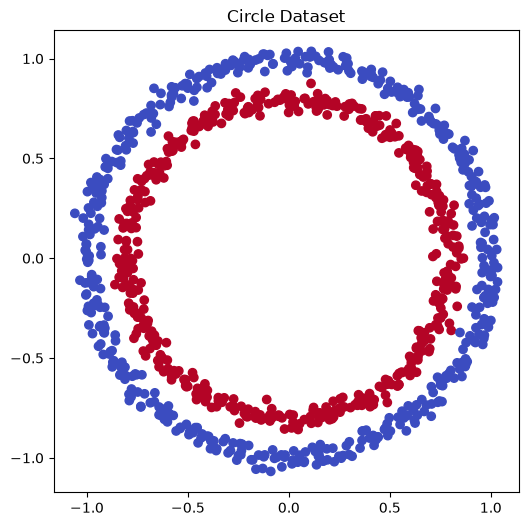


Basic Model
Loss: 0.7073020935058594
Accuracy: 0.5

Improved Model
Loss: 0.00891905277967453
Accuracy: 1.0


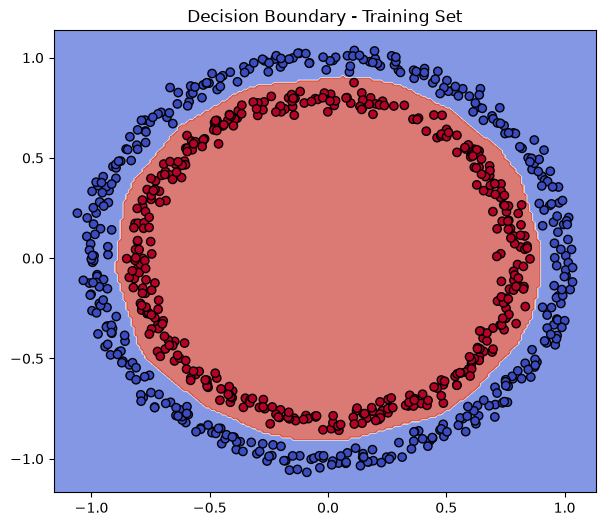

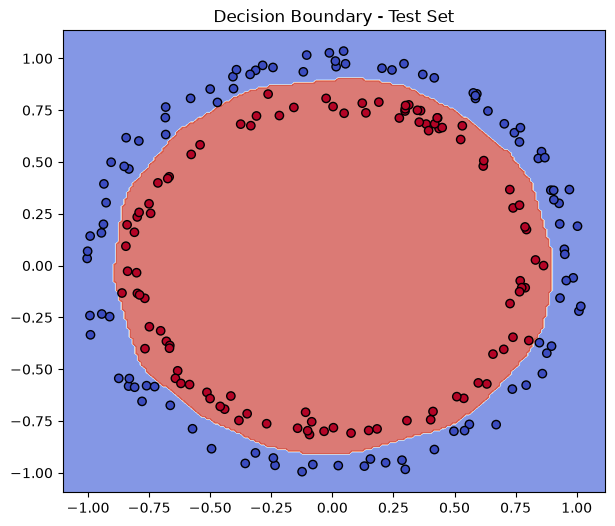

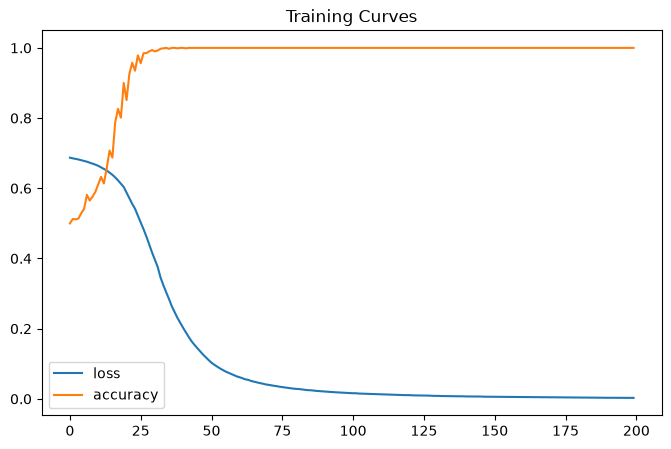


FINAL MODEL PERFORMANCE
Test Loss: 0.00891905277967453
Test Accuracy: 1.0


In [3]:
# ============================================================
# DAILY CHALLENGE: CLASSIFICATION WITH NEURAL NETWORKS
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 2. CREATE DATASET
# ------------------------------------------------------------
samples = 1000

X, y = make_circles(
    samples,
    noise=0.03,
    random_state=42
)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# ------------------------------------------------------------
# 3. VISUALIZE DATASET
# ------------------------------------------------------------
plt.figure(figsize=(6,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap="coolwarm"
)

plt.title("Circle Dataset")
plt.show()

# ------------------------------------------------------------
# 4. SPLIT DATA (80/20)
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------------------------
# 5. BASIC MODEL
# ------------------------------------------------------------
basic_model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

basic_model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["accuracy"]
)

history_basic = basic_model.fit(
    X_train,
    y_train,
    epochs=50,
    verbose=0
)

# ------------------------------------------------------------
# 6. EVALUATE BASIC MODEL
# ------------------------------------------------------------
basic_loss, basic_acc = basic_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\nBasic Model")
print("Loss:", basic_loss)
print("Accuracy:", basic_acc)

# ------------------------------------------------------------
# 7. IMPROVED MODEL WITH MORE LAYERS
# ------------------------------------------------------------
improved_model = tf.keras.Sequential([

    tf.keras.layers.Dense(
        16,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        16,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

improved_model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

history_improved = improved_model.fit(
    X_train,
    y_train,
    epochs=200,
    verbose=0
)

# ------------------------------------------------------------
# 8. EVALUATE IMPROVED MODEL
# ------------------------------------------------------------
improved_loss, improved_acc = improved_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\nImproved Model")
print("Loss:", improved_loss)
print("Accuracy:", improved_acc)

# ------------------------------------------------------------
# 9. FUNCTION TO PLOT DECISION BOUNDARY
# ------------------------------------------------------------
def plot_decision_boundary(model, X, y):

    x_min, x_max = (
        X[:,0].min() - 0.1,
        X[:,0].max() + 0.1
    )

    y_min, y_max = (
        X[:,1].min() - 0.1,
        X[:,1].max() + 0.1
    )

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    X_grid = np.c_[xx.ravel(), yy.ravel()]

    predictions = model.predict(
        X_grid,
        verbose=0
    )

    if predictions.shape[-1] == 1:
        predictions = (predictions > 0.5).astype(int)

    predictions = predictions.reshape(xx.shape)

    plt.contourf(
        xx,
        yy,
        predictions,
        alpha=0.7,
        cmap="coolwarm"
    )

    plt.scatter(
        X[:,0],
        X[:,1],
        c=y,
        cmap="coolwarm",
        edgecolor="black"
    )

# ------------------------------------------------------------
# 10. DECISION BOUNDARY - TRAIN SET
# ------------------------------------------------------------
plt.figure(figsize=(7,6))

plot_decision_boundary(
    improved_model,
    X_train,
    y_train
)

plt.title("Decision Boundary - Training Set")
plt.show()

# ------------------------------------------------------------
# 11. DECISION BOUNDARY - TEST SET
# ------------------------------------------------------------
plt.figure(figsize=(7,6))

plot_decision_boundary(
    improved_model,
    X_test,
    y_test
)

plt.title("Decision Boundary - Test Set")
plt.show()

# ------------------------------------------------------------
# 12. TRAINING CURVES
# ------------------------------------------------------------
pd.DataFrame(history_improved.history)[
    ["loss","accuracy"]
].plot(
    figsize=(8,5)
)

plt.title("Training Curves")
plt.show()

# ------------------------------------------------------------
# 13. FINAL RESULTS
# ------------------------------------------------------------
print("\n========================")
print("FINAL MODEL PERFORMANCE")
print("========================")

print("Test Loss:", improved_loss)
print("Test Accuracy:", improved_acc)

## 9. Key Takeaways
What I learned:

Binary classification predicts one of two classes.
Neural Networks can solve non-linear classification problems.
A simple model often performs poorly on the circle dataset.
Adding hidden layers and neurons improves learning.
ReLU helps the network learn complex patterns.
Sigmoid is suitable for binary classification output.
Adam usually converges faster than SGD.
Splitting data into training and testing sets helps evaluate generalization.
Decision boundaries are very useful for understanding model predictions.
Hyperparameter tuning (layers, neurons, optimizer, epochs) can greatly improve accuracy.